# 01. EDA — 난임 환자 임신 성공 여부 예측
**평가지표**: ROC-AUC  
**목표**: 데이터 구조 파악 → 결측치 패턴 분석 → 피처별 타겟 관계 확인

## 0. 환경 세팅

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display
import platform
import warnings
warnings.filterwarnings('ignore')
 
sns.set_style('whitegrid')

# OS별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin': # Mac
    plt.rcParams['font.family'] = 'AppleGothic'
else: # Linux/Colab 등
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지 및 DPI 설정
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

TARGET = '임신 성공 여부'

In [2]:
# 데이터 로드
train = pd.read_csv('../data/train.csv')
test  = pd.read_csv('../data/test.csv')

print(f'train: {train.shape}  |  test: {test.shape}')
train.head(3)

train: (256351, 69)  |  test: (90067, 68)


,ID,시술 시기 코드,시술 당시 나이,임신 시도 또는 마지막 임신 경과 연수,시술 유형,특정 시술 유형,배란 자극 여부,배란 유도 유형,단일 배아 이식 여부,착상 전 유전 검사 사용 여부,...,기증 배아 사용 여부,대리모 여부,PGD 시술 여부,PGS 시술 여부,난자 채취 경과일,난자 해동 경과일,난자 혼합 경과일,배아 이식 경과일,배아 해동 경과일,임신 성공 여부
0,TRAIN_000000,TRZKPL,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0
1,TRAIN_000001,TRYBLT,만45-50세,NaN,IVF,ICSI,0,알 수 없음,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
2,TRAIN_000002,TRVNRY,만18-34세,NaN,IVF,IVF,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,2.0,NaN,0


## 1. 기본 구조 파악

In [3]:
# 컬럼 타입 요약
dtype_summary = train.dtypes.value_counts()
print('컬럼 타입:\n', dtype_summary)
print()
train.info()

컬럼 타입:
 float64    29
str        21
int64      19
Name: count, dtype: int64

<class 'pandas.DataFrame'>
RangeIndex: 256351 entries, 0 to 256350
Data columns (total 69 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     256351 non-null  str    
 1   시술 시기 코드               256351 non-null  str    
 2   시술 당시 나이               256351 non-null  str    
 3   임신 시도 또는 마지막 임신 경과 연수  9370 non-null    float64
 4   시술 유형                  256351 non-null  str    
 5   특정 시술 유형               256349 non-null  str    
 6   배란 자극 여부               256351 non-null  int64  
 7   배란 유도 유형               256351 non-null  str    
 8   단일 배아 이식 여부            250060 non-null  float64
 9   착상 전 유전 검사 사용 여부       2718 non-null    float64
 10  착상 전 유전 진단 사용 여부       250060 non-null  float64
 11  남성 주 불임 원인             256351 non-null  int64  
 12  남성 부 불임 원인             256351 non-null  int64  
 13  여성 주 불임 원인             

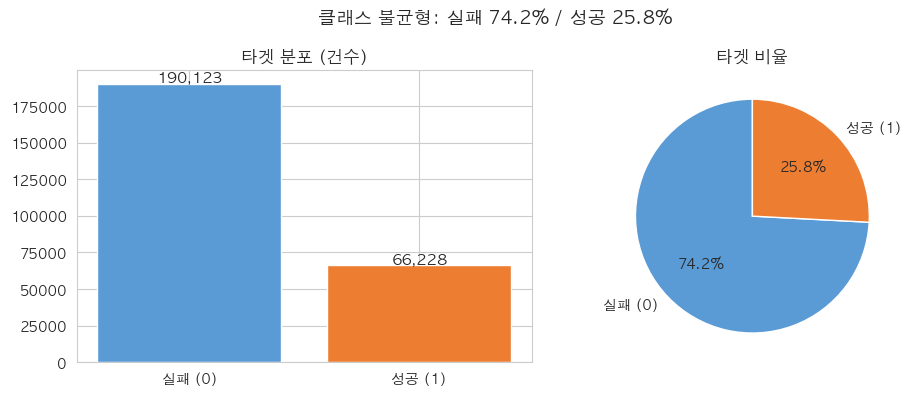

→ 클래스 불균형 존재. 모델 학습 시 scale_pos_weight 또는 class_weight 설정 필요


In [4]:
# 타겟 분포
target_counts = train[TARGET].value_counts()
target_ratio  = train[TARGET].value_counts(normalize=True)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].bar(['실패 (0)', '성공 (1)'], target_counts.values, color=['#5b9bd5','#ed7d31'])
ax[0].set_title('타겟 분포 (건수)')
for i, v in enumerate(target_counts.values):
    ax[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=11)

ax[1].pie(target_ratio.values, labels=['실패 (0)', '성공 (1)'],
          autopct='%1.1f%%', colors=['#5b9bd5','#ed7d31'], startangle=90)
ax[1].set_title('타겟 비율')

plt.suptitle(f'클래스 불균형: 실패 {target_ratio[0]:.1%} / 성공 {target_ratio[1]:.1%}', fontsize=13)
plt.tight_layout()
plt.show()
print('→ 클래스 불균형 존재. 모델 학습 시 scale_pos_weight 또는 class_weight 설정 필요')

## 2. 결측치 분석

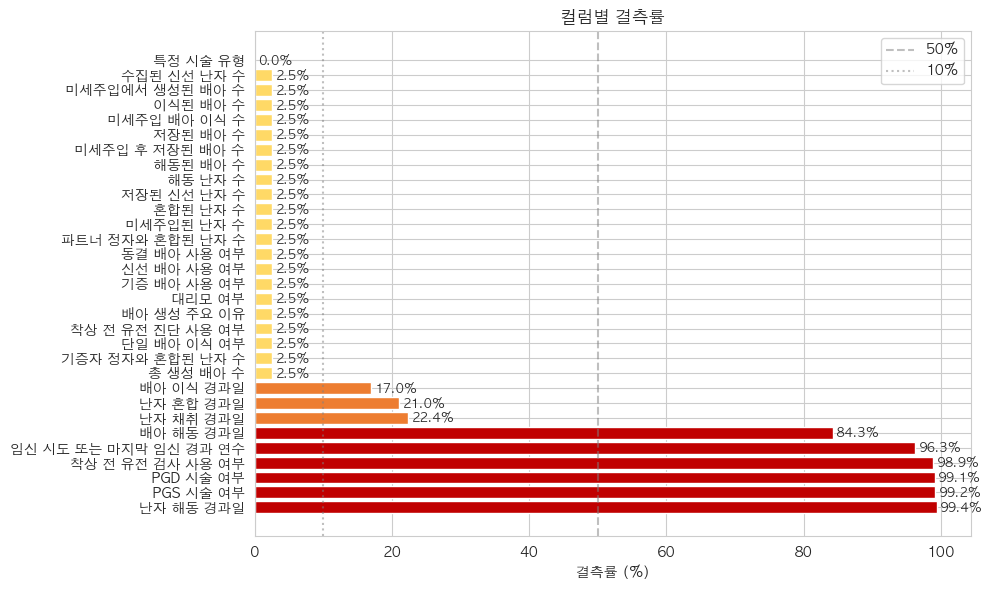

,결측 건수,결측률(%)
난자 해동 경과일,254915,99.4
PGS 시술 여부,254422,99.2
PGD 시술 여부,254172,99.1
착상 전 유전 검사 사용 여부,253633,98.9
임신 시도 또는 마지막 임신 경과 연수,246981,96.3
배아 해동 경과일,215982,84.3
난자 채취 경과일,57488,22.4
난자 혼합 경과일,53735,21.0
배아 이식 경과일,43566,17.0
총 생성 배아 수,6291,2.5


In [5]:
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(1)
missing_df = pd.DataFrame({'결측 건수': missing, '결측률(%)': missing_pct})
missing_df = missing_df[missing_df['결측 건수'] > 0].sort_values('결측률(%)', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#c00000' if p > 50 else '#ed7d31' if p > 10 else '#ffd966'
          for p in missing_df['결측률(%)']]
bars = ax.barh(missing_df.index, missing_df['결측률(%)'], color=colors)
ax.set_xlabel('결측률 (%)')
ax.set_title('컬럼별 결측률')
ax.axvline(50, color='gray', linestyle='--', alpha=0.5, label='50%')
ax.axvline(10, color='gray', linestyle=':', alpha=0.5, label='10%')
ax.legend()
for bar, pct in zip(bars, missing_df['결측률(%)']):
    ax.text(pct + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

missing_df

In [6]:
# 결측치 그룹 분류
high_missing   = missing_df[missing_df['결측률(%)'] >= 84].index.tolist()  # 84%+
mid_missing    = missing_df[(missing_df['결측률(%)'] >= 10) & (missing_df['결측률(%)'] < 84)].index.tolist()
low_missing    = missing_df[missing_df['결측률(%)'] < 10].index.tolist()

print('📌 결측 84%+ (제거 or 이진 플래그 검토):', high_missing)
print()
print('📌 결측 10~84% (이진 플래그 + 중앙값/최빈값 대체):', mid_missing)
print()
print('📌 결측 10% 미만 (중앙값/최빈값 대체):', low_missing)

📌 결측 84%+ (제거 or 이진 플래그 검토): ['난자 해동 경과일', 'PGS 시술 여부', 'PGD 시술 여부', '착상 전 유전 검사 사용 여부', '임신 시도 또는 마지막 임신 경과 연수', '배아 해동 경과일']

📌 결측 10~84% (이진 플래그 + 중앙값/최빈값 대체): ['난자 채취 경과일', '난자 혼합 경과일', '배아 이식 경과일']

📌 결측 10% 미만 (중앙값/최빈값 대체): ['총 생성 배아 수', '기증자 정자와 혼합된 난자 수', '단일 배아 이식 여부', '착상 전 유전 진단 사용 여부', '배아 생성 주요 이유', '대리모 여부', '기증 배아 사용 여부', '신선 배아 사용 여부', '동결 배아 사용 여부', '파트너 정자와 혼합된 난자 수', '미세주입된 난자 수', '혼합된 난자 수', '저장된 신선 난자 수', '해동 난자 수', '해동된 배아 수', '미세주입 후 저장된 배아 수', '저장된 배아 수', '미세주입 배아 이식 수', '이식된 배아 수', '미세주입에서 생성된 배아 수', '수집된 신선 난자 수', '특정 시술 유형']


In [7]:
# Zero-variance 컬럼 (제거 대상)
num_cols = train.select_dtypes(include=np.number).columns
zero_var_cols = [c for c in num_cols if train[c].std() == 0 and c != TARGET]
print('Zero-variance 컬럼 (학습에 무의미 → 제거):')
for c in zero_var_cols:
    print(f'  - {c}: 유일값 = {train[c].unique()}')

Zero-variance 컬럼 (학습에 무의미 → 제거):
  - 착상 전 유전 검사 사용 여부: 유일값 = [nan  1.]
  - 불임 원인 - 여성 요인: 유일값 = [0]
  - PGD 시술 여부: 유일값 = [nan  1.]
  - PGS 시술 여부: 유일값 = [nan  1.]
  - 난자 채취 경과일: 유일값 = [ 0. nan]


## 3. 범주형 피처 분석

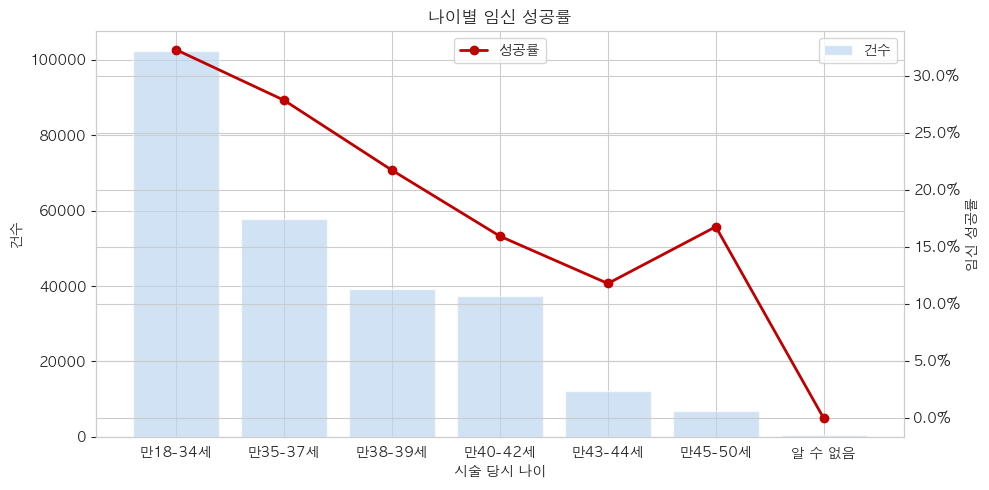

→ 나이 ↑ = 성공률 ↓ (강한 음의 상관). 나이는 중요한 피처임


In [8]:
# 나이별 임신 성공률
age_order = ['만18-34세','만35-37세','만38-39세','만40-42세','만43-44세','만45-50세','알 수 없음']
age_stats = train.groupby('시술 당시 나이')[TARGET].agg(['mean','count']).reindex(age_order)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.bar(age_stats.index, age_stats['count'], color='#bdd7ee', alpha=0.7, label='건수')
ax2.plot(age_stats.index, age_stats['mean'], 'o-', color='#c00000', linewidth=2, label='성공률')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

ax1.set_xlabel('시술 당시 나이')
ax1.set_ylabel('건수')
ax2.set_ylabel('임신 성공률')
ax1.set_title('나이별 임신 성공률')
ax1.legend(loc='upper right')
ax2.legend(loc='upper center')
plt.tight_layout()
plt.show()
print('→ 나이 ↑ = 성공률 ↓ (강한 음의 상관). 나이는 중요한 피처임')

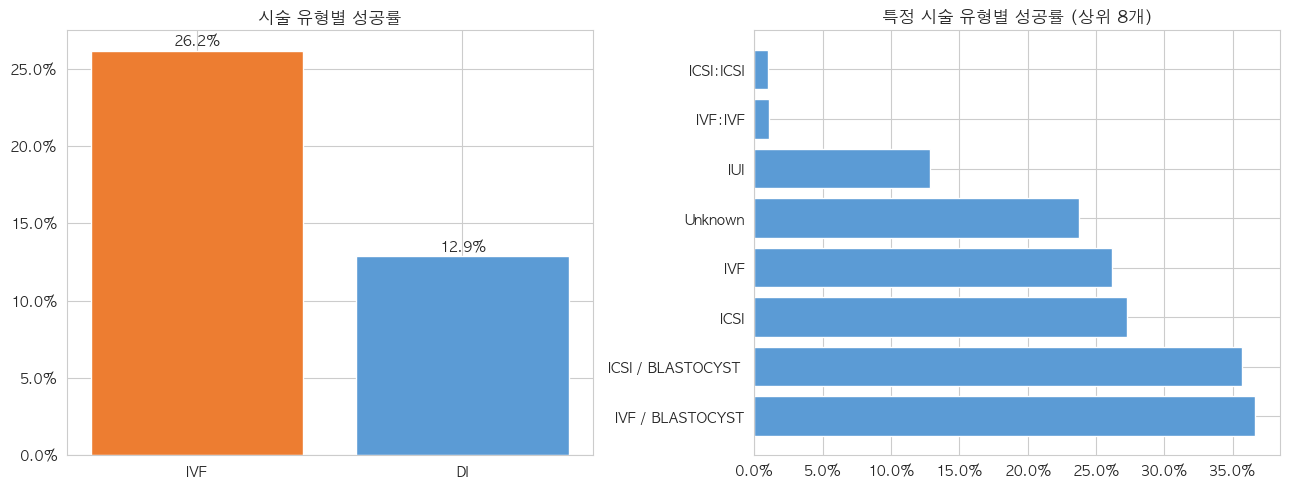

In [9]:
# 시술 유형 / 특정 시술 유형
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 시술 유형
type_stats = train.groupby('시술 유형')[TARGET].mean().sort_values(ascending=False)
axes[0].bar(type_stats.index, type_stats.values, color=['#ed7d31','#5b9bd5'])
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].set_title('시술 유형별 성공률')
for i, v in enumerate(type_stats.values):
    axes[0].text(i, v + 0.003, f'{v:.1%}', ha='center')

# 특정 시술 유형 (상위 8개)
top_types = train['특정 시술 유형'].value_counts().head(8).index
spec_stats = train[train['특정 시술 유형'].isin(top_types)].groupby('특정 시술 유형')[TARGET].mean().sort_values(ascending=False)
axes[1].barh(spec_stats.index, spec_stats.values, color='#5b9bd5')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].set_title('특정 시술 유형별 성공률 (상위 8개)')

plt.tight_layout()
plt.show()

## 4. 수치형 피처 분석

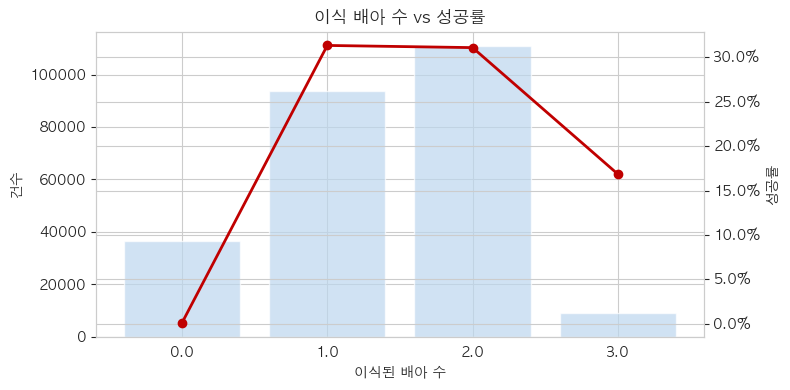

→ 배아 0개는 성공률 0.1%. 1~2개가 최적. 3개는 오히려 낮아짐


In [10]:
# 이식된 배아 수 vs 성공률
embryo_stats = train.groupby('이식된 배아 수')[TARGET].agg(['mean','count'])

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()
ax1.bar(embryo_stats.index.astype(str), embryo_stats['count'], color='#bdd7ee', alpha=0.7)
ax2.plot(embryo_stats.index.astype(str), embryo_stats['mean'], 'o-', color='#c00000', linewidth=2)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax1.set_xlabel('이식된 배아 수')
ax1.set_ylabel('건수')
ax2.set_ylabel('성공률')
ax1.set_title('이식 배아 수 vs 성공률')
plt.tight_layout()
plt.show()
print('→ 배아 0개는 성공률 0.1%. 1~2개가 최적. 3개는 오히려 낮아짐')

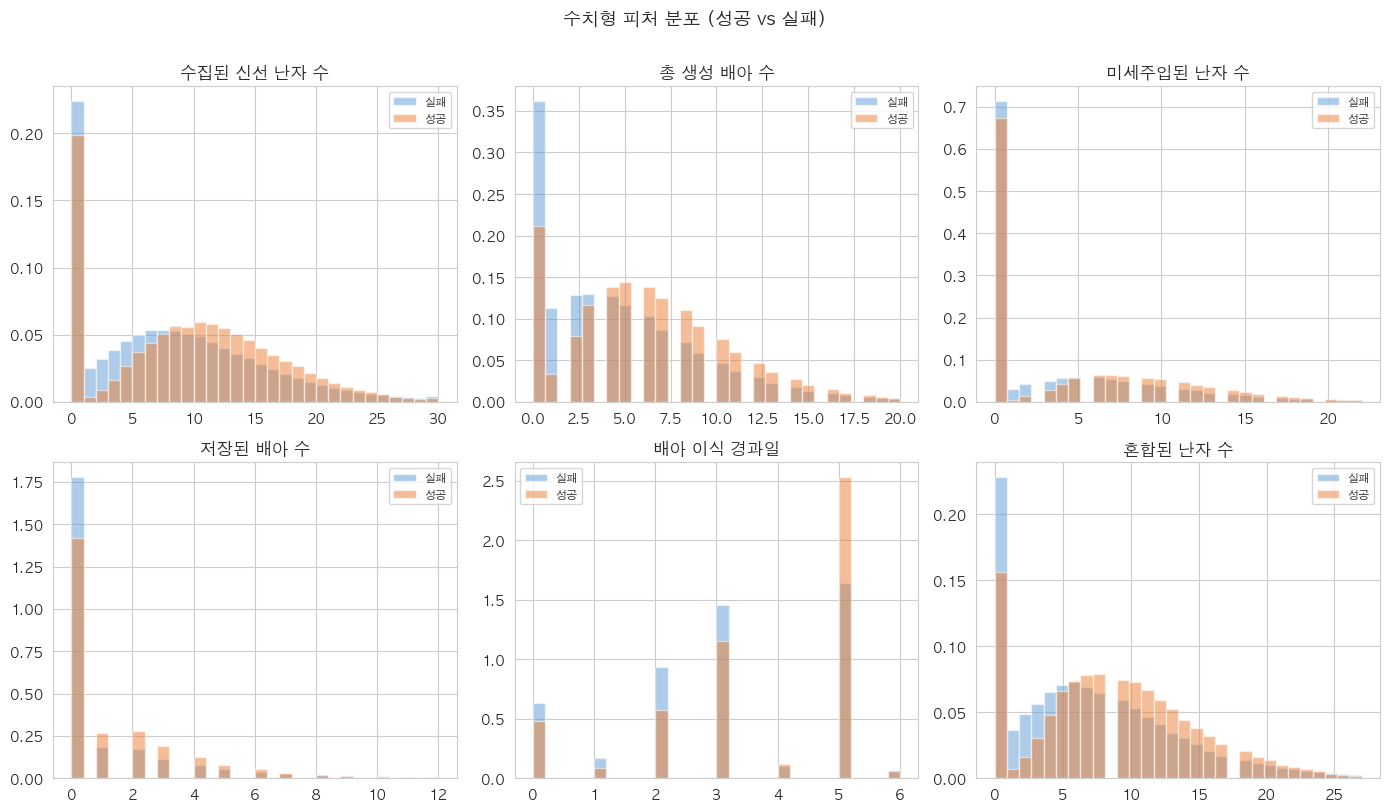

In [11]:
# 수치형 피처 분포 (성공 vs 실패)
num_features = [
    '수집된 신선 난자 수', '총 생성 배아 수', '미세주입된 난자 수',
    '저장된 배아 수', '배아 이식 경과일', '혼합된 난자 수'
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    data0 = train[train[TARGET]==0][col].dropna()
    data1 = train[train[TARGET]==1][col].dropna()
    # 이상치 제거 (시각화 목적)
    p99 = train[col].quantile(0.99)
    data0 = data0[data0 <= p99]
    data1 = data1[data1 <= p99]
    axes[i].hist(data0, bins=30, alpha=0.5, label='실패', color='#5b9bd5', density=True)
    axes[i].hist(data1, bins=30, alpha=0.5, label='성공', color='#ed7d31', density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.suptitle('수치형 피처 분포 (성공 vs 실패)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

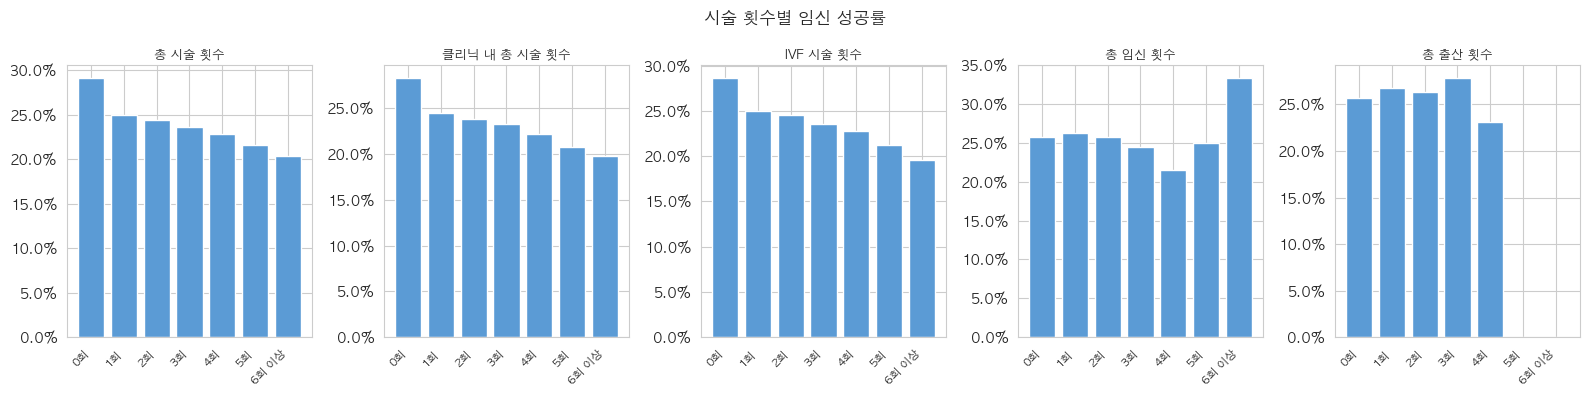

In [12]:
# 시술 횟수 관련 피처 분석
count_features = ['총 시술 횟수', '클리닉 내 총 시술 횟수', 'IVF 시술 횟수', '총 임신 횟수', '총 출산 횟수']

fig, axes = plt.subplots(1, len(count_features), figsize=(16, 4))
order_map = {'0회':0,'1회':1,'2회':2,'3회':3,'4회':4,'5회':5,'6회 이상':6}

for i, col in enumerate(count_features):
    stats = train.groupby(col)[TARGET].mean()
    stats = stats.reindex(sorted(stats.index, key=lambda x: order_map.get(x, 99)))
    axes[i].bar(range(len(stats)), stats.values, color='#5b9bd5')
    axes[i].set_xticks(range(len(stats)))
    axes[i].set_xticklabels(stats.index, rotation=45, ha='right', fontsize=8)
    axes[i].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[i].set_title(col, fontsize=9)

plt.suptitle('시술 횟수별 임신 성공률', fontsize=12)
plt.tight_layout()
plt.show()

## 5. 상관관계 분석

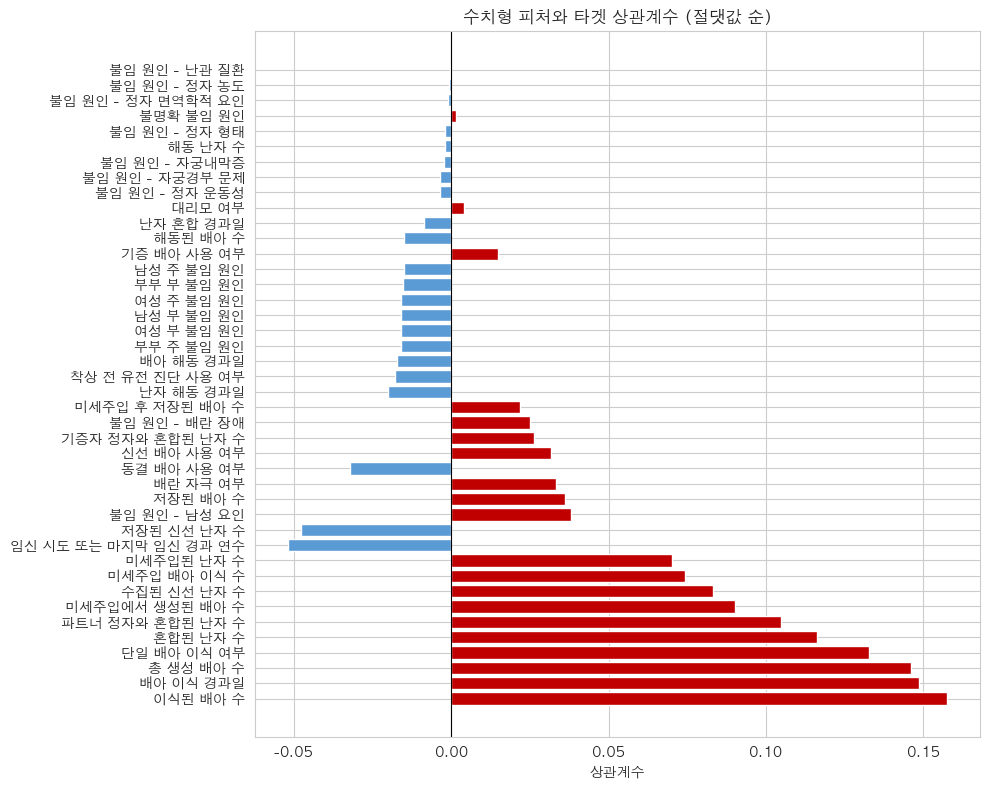

In [13]:
# 수치형 피처 상관관계 (타겟 포함)
# zero-variance 컬럼 제외
zero_var_cols = ['착상 전 유전 검사 사용 여부','불임 원인 - 여성 요인','PGD 시술 여부','PGS 시술 여부','난자 채취 경과일']

num_df = train.select_dtypes(include=np.number).drop(columns=zero_var_cols, errors='ignore')
corr_with_target = num_df.corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#c00000' if v > 0 else '#5b9bd5' for v in corr_with_target.values]
ax.barh(corr_with_target.index, corr_with_target.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('상관계수')
ax.set_title('수치형 피처와 타겟 상관계수 (절댓값 순)')
plt.tight_layout()
plt.show()

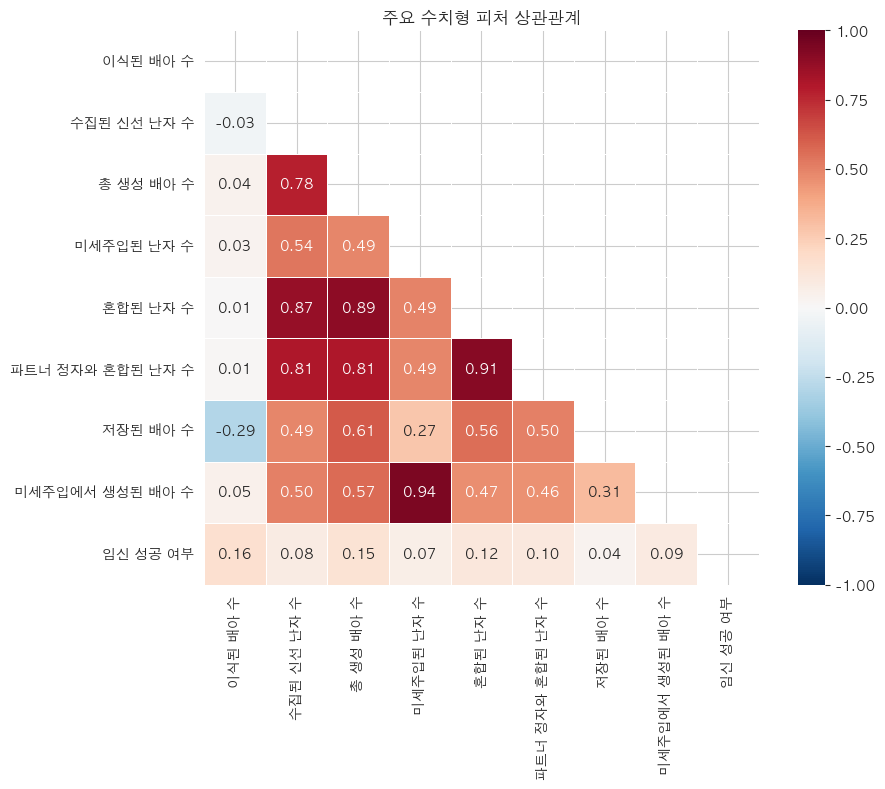

→ 난자/배아 관련 피처들이 서로 높은 상관관계. 다중공선성 주의


In [14]:
# 주요 피처 간 상관관계 히트맵
key_cols = [
    '이식된 배아 수','수집된 신선 난자 수','총 생성 배아 수',
    '미세주입된 난자 수','혼합된 난자 수','파트너 정자와 혼합된 난자 수',
    '저장된 배아 수','미세주입에서 생성된 배아 수', TARGET
]

corr_matrix = train[key_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=ax, square=True, linewidths=0.5)
ax.set_title('주요 수치형 피처 상관관계')
plt.tight_layout()
plt.show()
print('→ 난자/배아 관련 피처들이 서로 높은 상관관계. 다중공선성 주의')

## 6. EDA 요약 및 전처리 전략

In [15]:
print('=' * 60)
print('EDA 요약')
print('=' * 60)
print()
print('[데이터 기본 정보]')
print(f'  train: {train.shape[0]:,}행 × {train.shape[1]}열')
print(f'  test : {test.shape[0]:,}행 × {test.shape[1]}열')
print(f'  클래스 불균형: 실패 {(train[TARGET]==0).mean():.1%} / 성공 {(train[TARGET]==1).mean():.1%}')
print()
print('[제거 대상 컬럼]')
print('  - Zero-variance: 착상 전 유전 검사 사용 여부, 불임 원인-여성 요인,')
print('                   PGD 시술 여부, PGS 시술 여부, 난자 채취 경과일')
print()
print('[결측치 처리 전략]')
print('  - 결측률 84%+: 난자 해동 경과일, 배아 해동 경과일, PGS/PGD/착상전유전검사')
print('    → 이진 플래그 피처 생성 후 제거 검토')
print('  - 결측률 10~84%: 난자 채취/혼합/이식 경과일')
print('    → 이진 플래그 생성 + train 기반 중앙값 대체 (leakage 주의!)')
print('  - 결측률 2.5%: 나머지 컬럼들')
print('    → train 기반 중앙값/최빈값 대체')
print()
print('[인코딩 전략]')
print('  - 순서형: 시술 당시 나이, 시술 횟수 계열 → Ordinal Encoding')
print('  - 명목형: 시술 유형, 특정 시술 유형, 난자/정자 출처 → Label Encoding')
print('  - 모두 train fit → test transform (leakage 방지)')
print()
print('[주요 인사이트]')
print('  - 나이 ↑ → 성공률 ↓ (가장 강한 음의 상관)')
print('  - 이식 배아 1~2개가 최적 (0개, 3개는 낮음)')
print('  - IVF가 DI보다 성공률 2배')
print('  - 난자/배아 수 관련 피처들이 서로 높은 상관관계')
print()
print('[추천 모델]')
print('  1. LightGBM (기준선)')
print('  2. XGBoost')
print('  3. CatBoost (범주형 자동 처리)')
print('  4. 앙상블 (Soft Voting / Stacking)')

EDA 요약

[데이터 기본 정보]
  train: 256,351행 × 69열
  test : 90,067행 × 68열
  클래스 불균형: 실패 74.2% / 성공 25.8%

[제거 대상 컬럼]
  - Zero-variance: 착상 전 유전 검사 사용 여부, 불임 원인-여성 요인,
                   PGD 시술 여부, PGS 시술 여부, 난자 채취 경과일

[결측치 처리 전략]
  - 결측률 84%+: 난자 해동 경과일, 배아 해동 경과일, PGS/PGD/착상전유전검사
    → 이진 플래그 피처 생성 후 제거 검토
  - 결측률 10~84%: 난자 채취/혼합/이식 경과일
    → 이진 플래그 생성 + train 기반 중앙값 대체 (leakage 주의!)
  - 결측률 2.5%: 나머지 컬럼들
    → train 기반 중앙값/최빈값 대체

[인코딩 전략]
  - 순서형: 시술 당시 나이, 시술 횟수 계열 → Ordinal Encoding
  - 명목형: 시술 유형, 특정 시술 유형, 난자/정자 출처 → Label Encoding
  - 모두 train fit → test transform (leakage 방지)

[주요 인사이트]
  - 나이 ↑ → 성공률 ↓ (가장 강한 음의 상관)
  - 이식 배아 1~2개가 최적 (0개, 3개는 낮음)
  - IVF가 DI보다 성공률 2배
  - 난자/배아 수 관련 피처들이 서로 높은 상관관계

[추천 모델]
  1. LightGBM (기준선)
  2. XGBoost
  3. CatBoost (범주형 자동 처리)
  4. 앙상블 (Soft Voting / Stacking)
